In [1]:
import xarray as xr
import numpy as np
from osgeo import ogr, osr
from datetime import datetime,timedelta
import matplotlib.pylab as plt
import matplotlib
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
from matplotlib.dates import MonthLocator, YearLocator
from pyproj import Transformer
matplotlib.use('nbAgg')
import pandas as pd
from rasterstats import zonal_stats, gen_zonal_stats
from tqdm import *
# import pymannkendall as mk
from decimal import *
from matplotlib.patches import Polygon

import fiona
import rasterio
import rasterio.plot
import matplotlib as mpl

import sys
sys.path.insert(0,'/workspace/WorldPeatland/code/')
from gdal_sheep import *
from save_xarray_to_gtiff import *
import matplotlib.dates as mdates

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

/tmp/ipykernel_2931429/3777615979.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:
def format_e(n):
    a = '%E' % n
    return a.split('E')[0].rstrip('0').rstrip('.') + 'E' + a.split('E')[1]

### Site Name 

In [4]:
site='Degero'

In [5]:
path = f'/wp_data/sites/{site}/MODIS'

### Utils functions

In [6]:
def transform_coordinates(lon, lat, source_crs, target_crs):
    """
    Transforms coordinates from a source CRS to a target CRS.
    
    Parameters:
        lon (float): Longitude of the point.
        lat (float): Latitude of the point.
        source_crs (str): Source coordinate reference system in PROJ string format.
        target_crs (str): Target coordinate reference system in PROJ string format.
    
    Returns:
        tuple: Transformed coordinates (x, y).
    """
    transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)
    x, y = transformer.transform(lon, lat)
    return x, y

source_crs = "+proj=longlat +datum=WGS84 +no_defs"
target_crs = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +R=6371007.181 +units=m +no_defs"


In [7]:
def gdal_dt_doy(e, time):
    
    '''
    gdal_dt function will open the tif file as an osegeo gdal dataset 
    
    INPUTS:
        - e (str or tiff) - path the tiff file or the gdal dataset you want to 
            open and save its datetimes
        - time (string) - check how the time variable is written in the tiff metadata
    Outputs:
        - arr (np.array) - return arr of the gdal dataset
        - dts (list) - list of the datetimes 
        - saved_opn (osegeo gdal dataset) - saved dataset for its srs 
    '''
    
    # Create an empty list to store the datatimes 
    dts = []
    doys = []
    
    # Check if the input is a str which would be the tif file 
    # otherwise it is already an opened gdal dataset 
    if type(e) == str:
        # open the Dataset
        opn = gdal.Open(e)
    else:
        opn = e
        
    for i in range(1,opn.RasterCount + 1):
            
        rst = opn.GetRasterBand(i)
        meta = rst.GetMetadata()
        
        # the time data
        x = meta[time]
        # also check the metadata to see how is the format of datetime data
        dt_format = '%j'
        t = dt.strptime(x, dt_format)
            
        # append it to the list
        dts.append(t)
        
        # Calculate the day of the year (DOY) and append it to the list
        doy = t.timetuple().tm_yday
        doys.append(doy)
                        
    # save the last osegeodataset for its srs
    saved_opn = opn
        
    # open the array
    arr = opn.ReadAsArray()
    
    return arr, dts, saved_opn, doys

## Set the coordinates
Can get it from QGIS

In [8]:
# lon, lat = 19.57252792704577, 64.15089740461829

lon, lat = 19.58536769544787, 64.1878432937217

In [9]:
# Get the coordinates in sinusoidal x and y 
x, y = transform_coordinates(lon, lat, source_crs, target_crs)

In [10]:
# Pick a year to observe the anomalies and stats better
year = 2021

## LST

In [11]:
# LST DAY linear.smoothn.descaled
fpath = path + '/timeSeries/MYD11A1.061._LST_Day_1km.linear.smoothn.0.5.descaled.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstDay = create_xarr(opn, 'LST', arr, dts)

# LST DAY detrended
fpath = path + '/timeSeries/MYD11A1.061._LST_Day_1km.linear.smoothn.0.5.descaled.detrended.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstDayDetrended = create_xarr(opn, 'LST', arr, dts)

# LST NIGHT linear.smoothn.descaled
fpath = path + '/timeSeries/MYD11A1.061._LST_Night_1km.linear.smoothn.0.5.descaled.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstNight = create_xarr(opn, 'LST', arr, dts)

# LST NIGHT detrended
fpath = path + '/timeSeries/MYD11A1.061._LST_Night_1km.linear.smoothn.0.5.descaled.detrended.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstNightDetrended = create_xarr(opn, 'LST', arr, dts)

# LST DAY climatology mean
fpath = path + "/timeSeries/stats/_LST_Day_1km_climatology_mean.tif"
arr, dts, saved_opn, doys = gdal_dt_doy(fpath, 'dayofyear')
xr_lstDay_mean = create_xarr(saved_opn, '_LST_Day_1km', arr, doys)

# LST DAY climatology standard deviation 
fpath = path + "/timeSeries/stats/_LST_Day_1km_climatology_std.tif"
arr, dts, saved_opn, doys = gdal_dt_doy(fpath, 'dayofyear')
xr_lstDay_std = create_xarr(saved_opn, '_LST_Day_1km', arr, doys)

# calculate sigma # square root of the standard deviation 
ds_sigma_p = np.sqrt(xr_lstDay_std)

# Calculate error +-
ds_n = xr_lstDay_mean['_LST_Day_1km'] - ds_sigma_p
ds_p = xr_lstDay_mean['_LST_Day_1km'] + ds_sigma_p

# LST DAY anomalies
fpath = path + "/timeSeries/stats/_LST_Day_1km_anomalies.tif"
arr, dts, saved_opn = gdal_dt(fpath)
xr_lstDay_anomalies = create_xarr(saved_opn, '_LST_Day_1km', arr, dts)

In [12]:
# Actual smoothened Observations of LSTs
# Difference between day and night LST 
xr_lstDay['dif_LST'] = xr_lstDay['LST'] - xr_lstNight['LST']

# Actual smoothened Observations of LSTs
# Difference between day and night LST 
xr_lstDayDetrended['dif_LST_detrended'] = xr_lstDayDetrended['LST'] - xr_lstNightDetrended['LST']

<IPython.core.display.Javascript object>


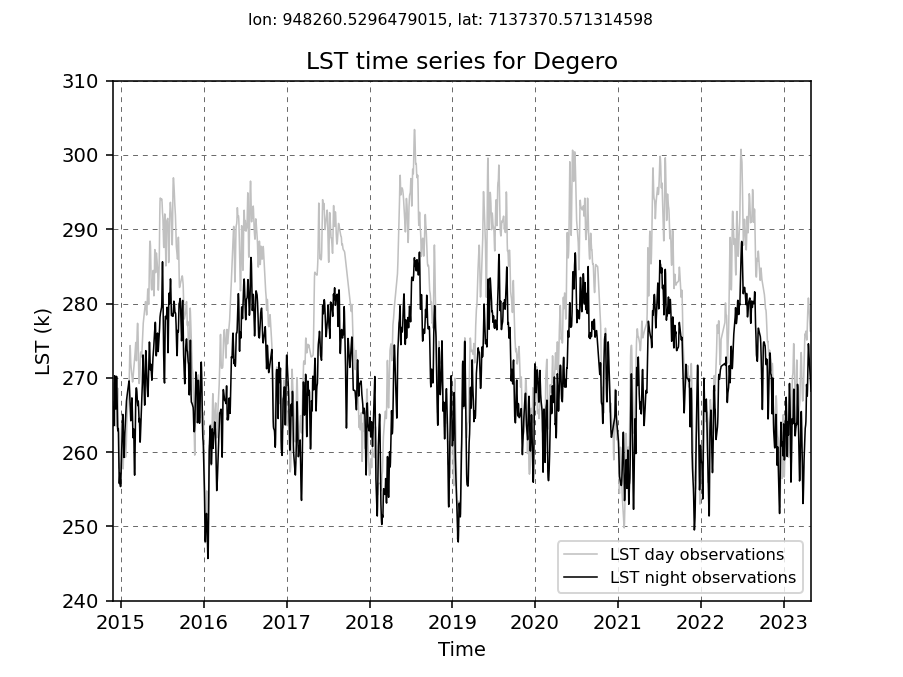

In [13]:
fig, ax = plt.subplots()

ax.plot(xr_lstDay['LST'].time.values, 
        xr_lstDay['LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='silver', label="LST day observations", linewidth=0.8)

ax.plot(xr_lstNight['LST'].time.values, 
        xr_lstNight['LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='black', label="LST night observations", linewidth=0.8)

ax.set_title(f'LST time series for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('LST (k)')

ax.set_ylim(240, 310)
ax.set_xlim([datetime(2014, 11, 25), datetime(2023, 5, 1)])
plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='lower right', fontsize='small')

# fig.savefig(f'/workspace/WorldPeatland/visualisation/ts_vis/{site}.lst.obs.png', dpi=300)

plt.show()

<IPython.core.display.Javascript object>


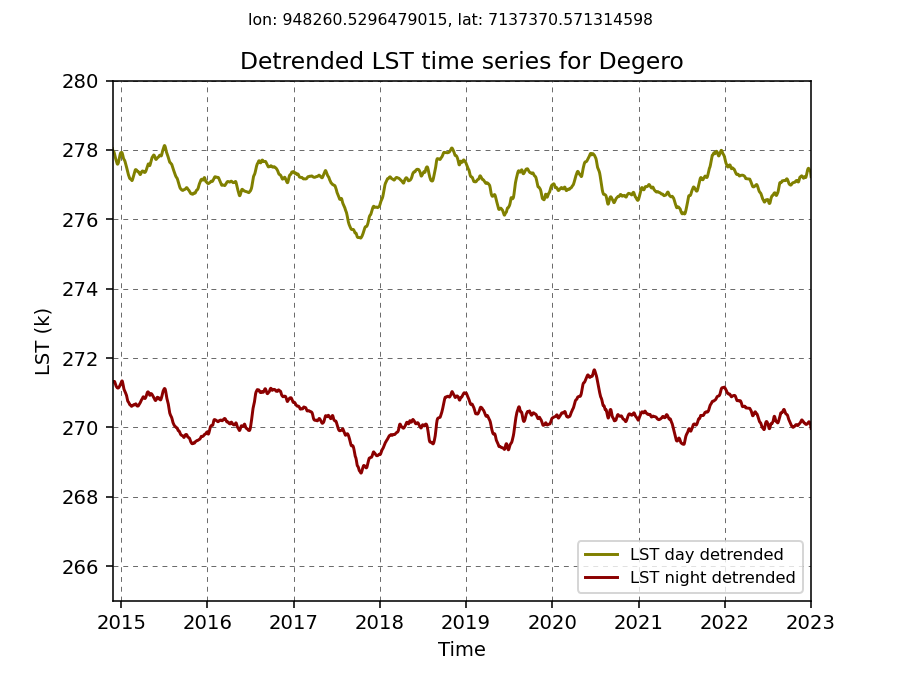

In [14]:
fig, ax = plt.subplots()

ax.plot(xr_lstDayDetrended['LST'].time.values, 
        xr_lstDayDetrended['LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='olive', label="LST day detrended")

ax.plot(xr_lstNightDetrended['LST'].time.values, 
        xr_lstNightDetrended['LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='darkred', label="LST night detrended")

ax.set_title(f'Detrended LST time series for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('LST (k)')

ax.set_ylim(265, 280)
ax.set_xlim([datetime(2014, 11, 25), datetime(2023, 1, 1)])

plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='lower right', fontsize='small')
# fig.savefig(f'/workspace/WorldPeatland/visualisation/ts_vis/{site}.lst.detrended.png', dpi=300)
plt.show()

<IPython.core.display.Javascript object>


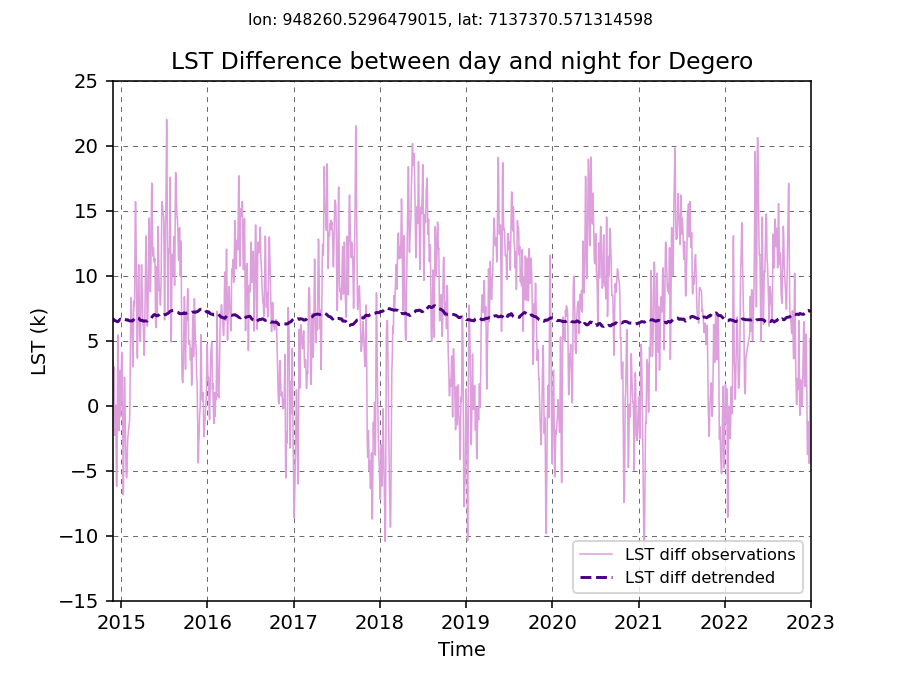

In [15]:
fig, ax = plt.subplots()

ax.plot(xr_lstDay['dif_LST'].time.values, 
        xr_lstDay['dif_LST'].sel(latitude=y, longitude=x, method='nearest').data,
       color='plum', label="LST diff observations", linewidth=0.8)

ax.plot(xr_lstDayDetrended['dif_LST_detrended'].time.values, 
        xr_lstDayDetrended['dif_LST_detrended'].sel(latitude=y, longitude=x, method='nearest').data,
       color='indigo', label="LST diff detrended",linestyle='--')

ax.set_title(f'LST Difference between day and night for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('LST (k)')
x
ax.set_ylim(-15,25)
ax.set_xlim([datetime(2014, 11, 25), datetime(2023, 1, 1)])

plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='lower right', fontsize='small')
# fig.savefig(f'/workspace/WorldPeatland/visualisation/ts_vis/{site}.lst.diff.png', dpi=300)
plt.show()

## Select the year you want to observe the LST DAY anomalies for 


In [16]:
year = 2021

In [17]:
# get the slice for the corresponding year 
xr_lstDay_anomalies_yr = xr_lstDay_anomalies.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
ds_descaled_yr = xr_lstDay.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))

<IPython.core.display.Javascript object>


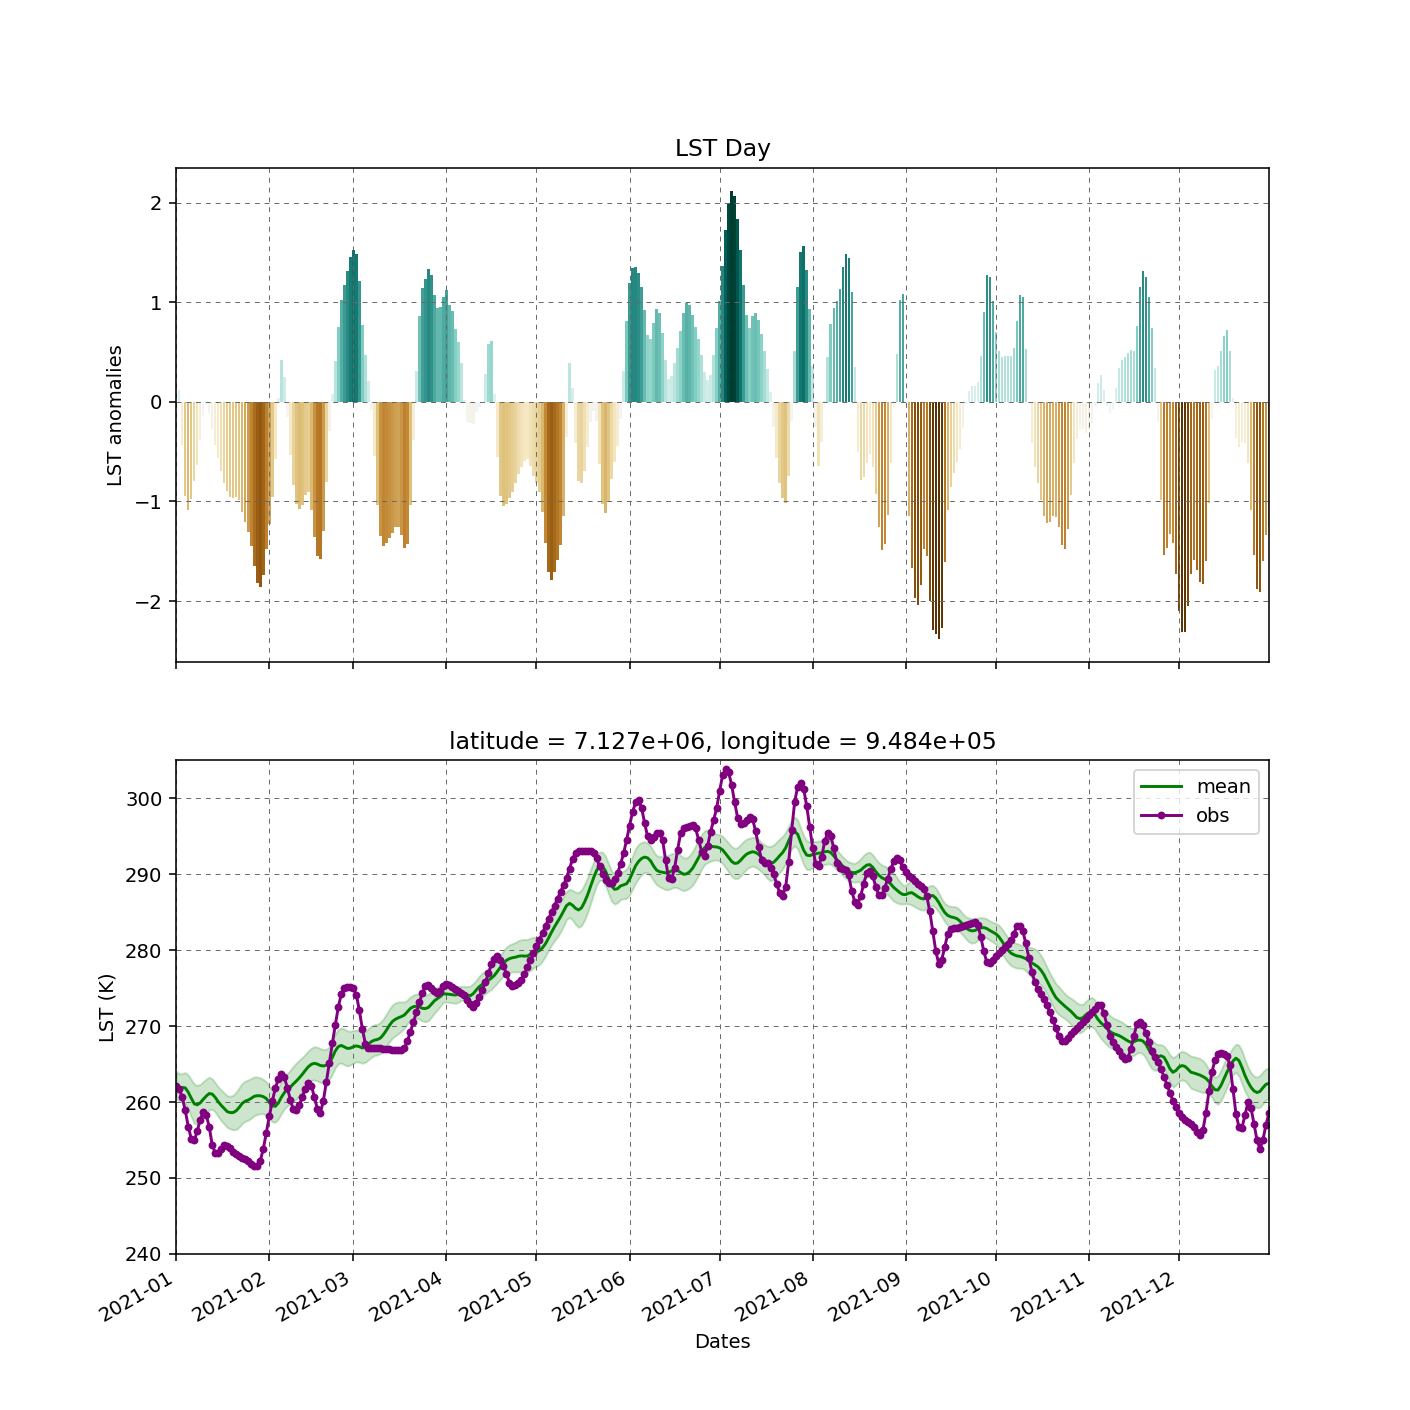

In [19]:
a = xr_lstDay_mean['_LST_Day_1km'].sel(longitude=x, latitude=y, method='nearest').values[:-1]
b = ds_p['_LST_Day_1km'].sel(longitude=x, latitude=y, method='nearest')[:-1]
c = ds_n['_LST_Day_1km'].sel(longitude=x, latitude=y, method='nearest')[:-1]
d = xr_lstDay_anomalies_yr['_LST_Day_1km'].sel(longitude=x, latitude=y, method='nearest')
date_t = xr_lstDay_anomalies_yr['time'].values

data = d.values  # set the xarray dataset into a numpy array to loop over the anomalies values only

fig, (ax, ox) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Normalize data for colormap
norm = Normalize(vmin=data.min(), vmax=data.max())
cmap = plt.get_cmap('BrBG')
colors = [cmap(norm(value)) for value in data]
ax.bar(date_t, data, color=colors)

plt.axhline(y=0., color='gray', linestyle=(0, (5, 5)), linewidth=0.8)
ax.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.set_xlim(date_t[0], date_t[-1])
ax.set_ylabel('LST anomalies')
ax.set_title('LST Day')

#########################################################

plt.plot(date_t, a, color='green', label='mean')
obs = xr_lstDay['LST'].sel(longitude=x, latitude=lat, method='nearest')
obs.plot(label='obs', color="purple", marker='.')

# create the error shaded area around the mean
ox.fill_between(date_t, b, c, alpha=0.2, color='green', interpolate=True)
ox.set_xlabel("Dates")
ox.set_ylabel("LST (K)")
ox.set_ylim(240, 305)

plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
plt.legend()
plt.show()

## Vegetation

### LAI

In [20]:
# linear.smoothn.descaled
fpath = path + '/timeSeries/MCD15A3H.061._Lai_500m.linear.smoothn.0.5.descaled.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lai = create_xarr(opn, 'lai', arr, dts)

# linear.smoothn.descaled.detrended
fpath = path + '/timeSeries/MCD15A3H.061._Lai_500m.linear.smoothn.0.5.descaled.detrended.tif'
arr, dts, opn = gdal_dt(fpath)
xr_laiDetrended = create_xarr(opn, 'lai', arr, dts)

<IPython.core.display.Javascript object>


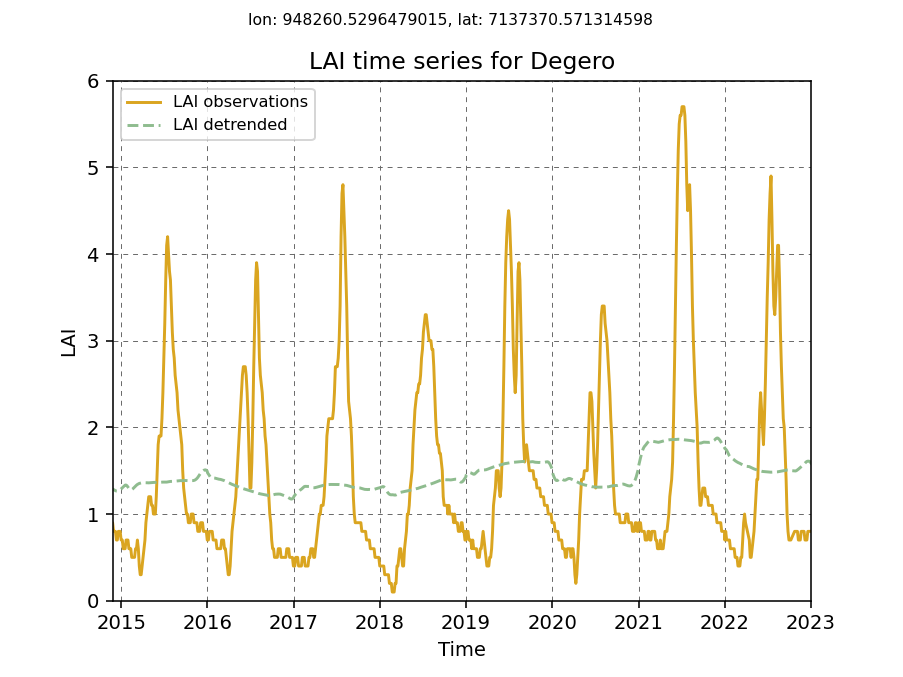

In [21]:
fig, ax = plt.subplots()

ax.plot(xr_lai['lai'].time.values, 
        xr_lai['lai'].sel(latitude=y, longitude=x, method='nearest').data,
       color='goldenrod', label="LAI observations")

ax.plot(xr_laiDetrended['lai'].time.values, 
        xr_laiDetrended['lai'].sel(latitude=y, longitude=x, method='nearest').data,
       color='darkseagreen', label="LAI detrended",linestyle='--')

ax.set_title(f'LAI time series for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('LAI')

ax.set_ylim(0,6)
ax.set_xlim([datetime(2014, 11, 25), datetime(2023, 1, 1)])

plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='upper left', fontsize='small')
# fig.savefig(f'/workspace/WorldPeatland/visualisation/ts_vis/{site}.lai.png', dpi=300)
plt.show()

In [22]:
fpath = f'/wp_data/sites/{site}/MODIS/MCD15A3H.061/h18v02/Lai_500m/degero.txt'
data = pd.read_csv(fpath, header=None)
data[data == 255] = np.nan
data = data*0.1

<IPython.core.display.Javascript object>


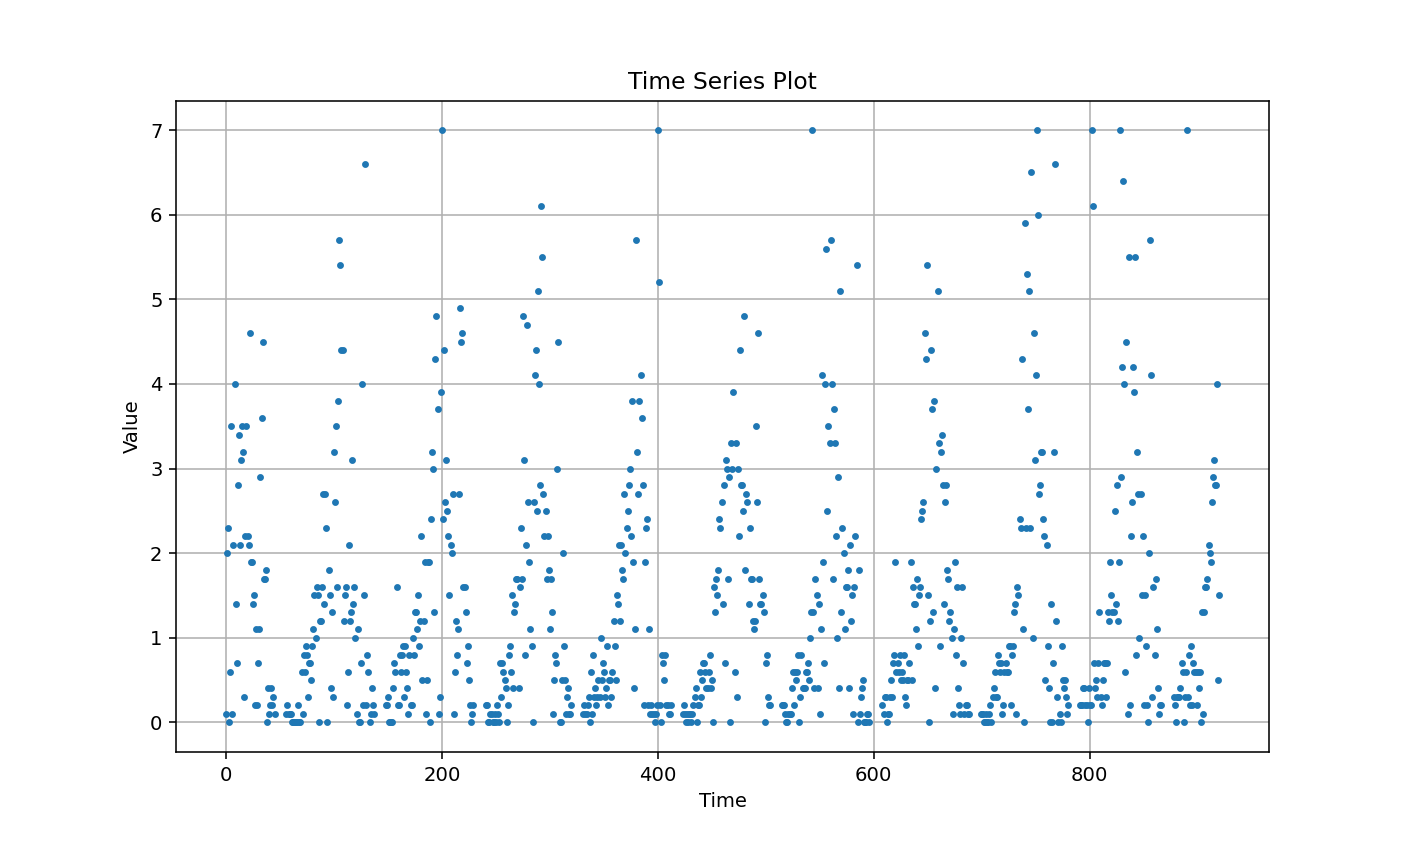

In [23]:
# Assuming the data is a single column, you can plot it like this:
plt.figure(figsize=(10, 6))
plt.plot(data, marker='.', linestyle=' ', markersize=5)
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True)
plt.show()


<IPython.core.display.Javascript object>


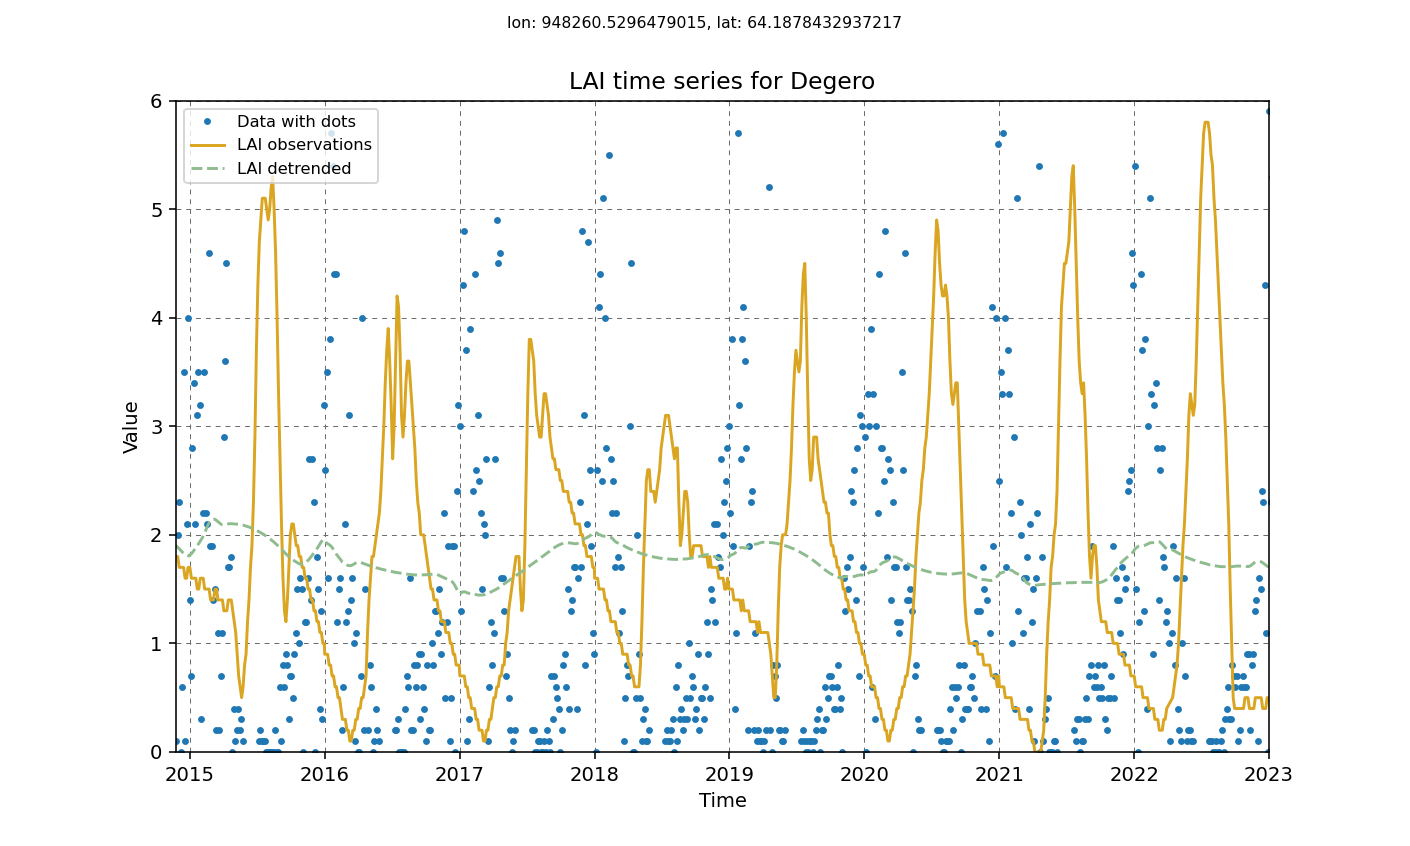

In [24]:
# Create a time range for the plot (assuming the data has a time index)
# Replace this with your actual time range if needed
time = pd.date_range(start='2014-11-25', periods=len(data), freq='4D')
x
# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data as dots (using markers)
ax.plot(time, data, marker='.', linestyle=' ', markersize=5, label='Data with dots')

# Example plotting for LAI observations (replace with actual data)
ax.plot(xr_lai['lai'].time.values, 
        xr_lai['lai'].sel(latitude=lat, longitude=x, method='nearest').data,
       color='goldenrod', label="LAI observations")

# Example plotting for LAI detrended (replace with actual data)
ax.plot(xr_laiDetrended['lai'].time.values, 
        xr_laiDetrended['lai'].sel(latitude=lat, longitude=x, method='nearest').data,
       color='darkseagreen', label="LAI detrended", linestyle='--')

# Set titles and labels
ax.set_title(f'LAI time series for {site}')
fig.suptitle(f'lon: {x}, lat: {lat}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('Value')

# Set axis limits (for the LAI range and time range)
ax.set_ylim(0, 6)
ax.set_xlim([datetime(2014, 11, 25), datetime(2023, 1, 1)])

# Add grid and legend
plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='upper left', fontsize='small')

# Show the plot
plt.show()


### Albedo 

In [25]:
# linear.smoothn.descaled
path_albedo = path + '/timeSeries/MCD43A3.061._Albedo_WSA_Band2.linear.smoothn.0.5.descaled.tif'

arr, dts, opn = gdal_dt(path_albedo)
xr_albedo = create_xarr(opn, 'albedo', arr, dts)

# linear.smoothn.descaled.detrended
path_albedoDetrended = path + '/timeSeries/MCD43A3.061._Albedo_WSA_Band2.linear.smoothn.0.5.descaled.detrended.tif'

arr, dts, opn = gdal_dt(path_albedoDetrended)
xr_albedoDetrended = create_xarr(opn, 'albedo', arr, dts)

# only interpolated 
path_albedo_inter = f'/wp_data/sites/{site}/MODIS/MCD43A3.061/h18v02/Albedo_WSA_Band2/interpolated/MCD43A3.061._Albedo_WSA_Band2.linear.tif'
arr, dts, opn = gdal_dt(path_albedo_inter)
arr = arr *0.001
xr_albedo_inter = create_xarr(opn, 'albedo', arr, dts)



<IPython.core.display.Javascript object>


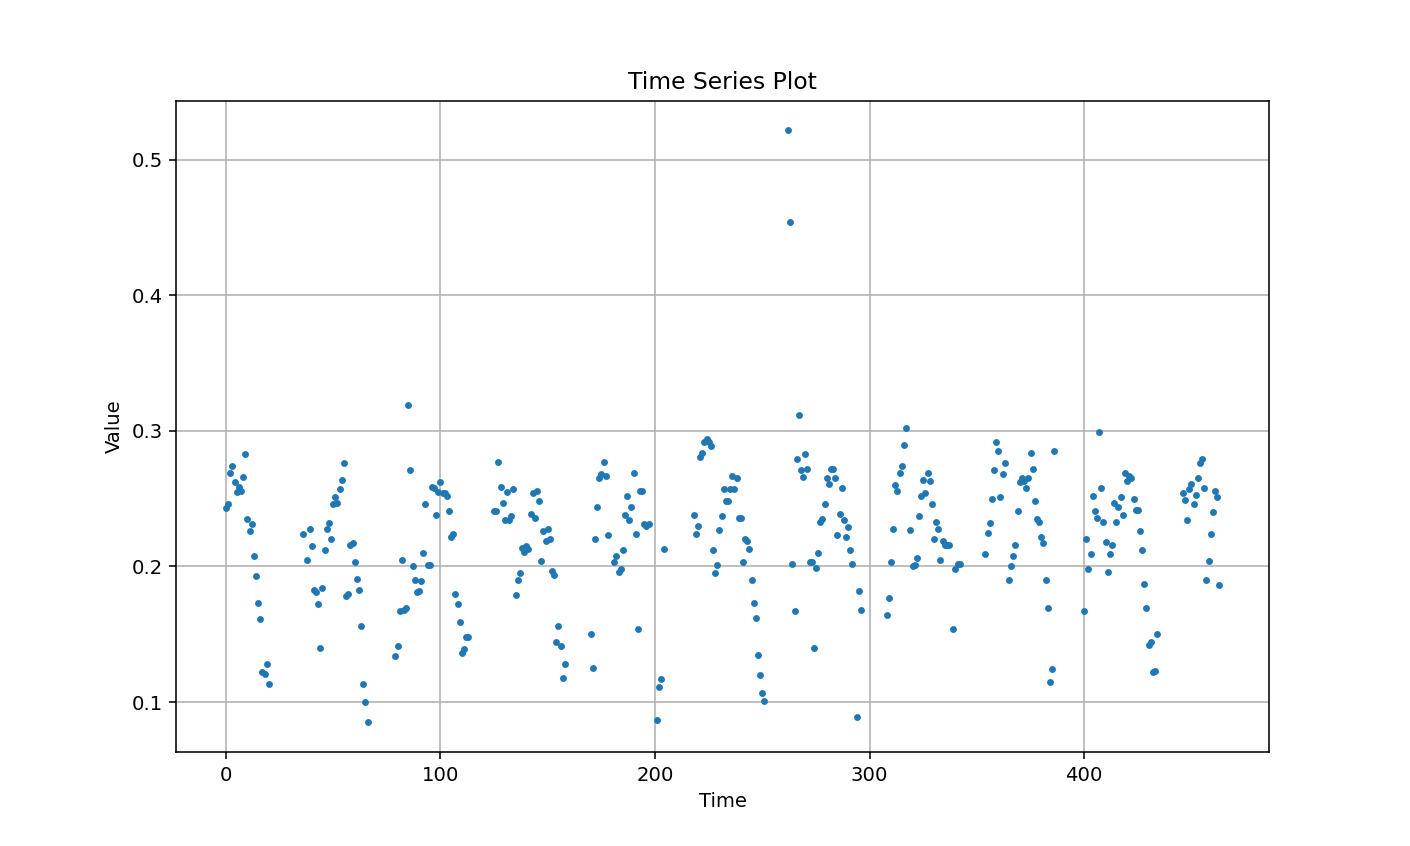

In [26]:
fpath = f'/wp_data/sites/{site}/MODIS/MCD43A3.061/h18v02/Albedo_WSA_Band2/degero.txt'
data = pd.read_csv(fpath, header=None)
data[data == 32767] = np.nan
data = data*0.001

# Assuming the data is a single column, you can plot it like this:
plt.figure(figsize=(10, 6))
plt.plot(data, marker='.', linestyle=' ', markersize=5)
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True)
plt.show()

<IPython.core.display.Javascript object>


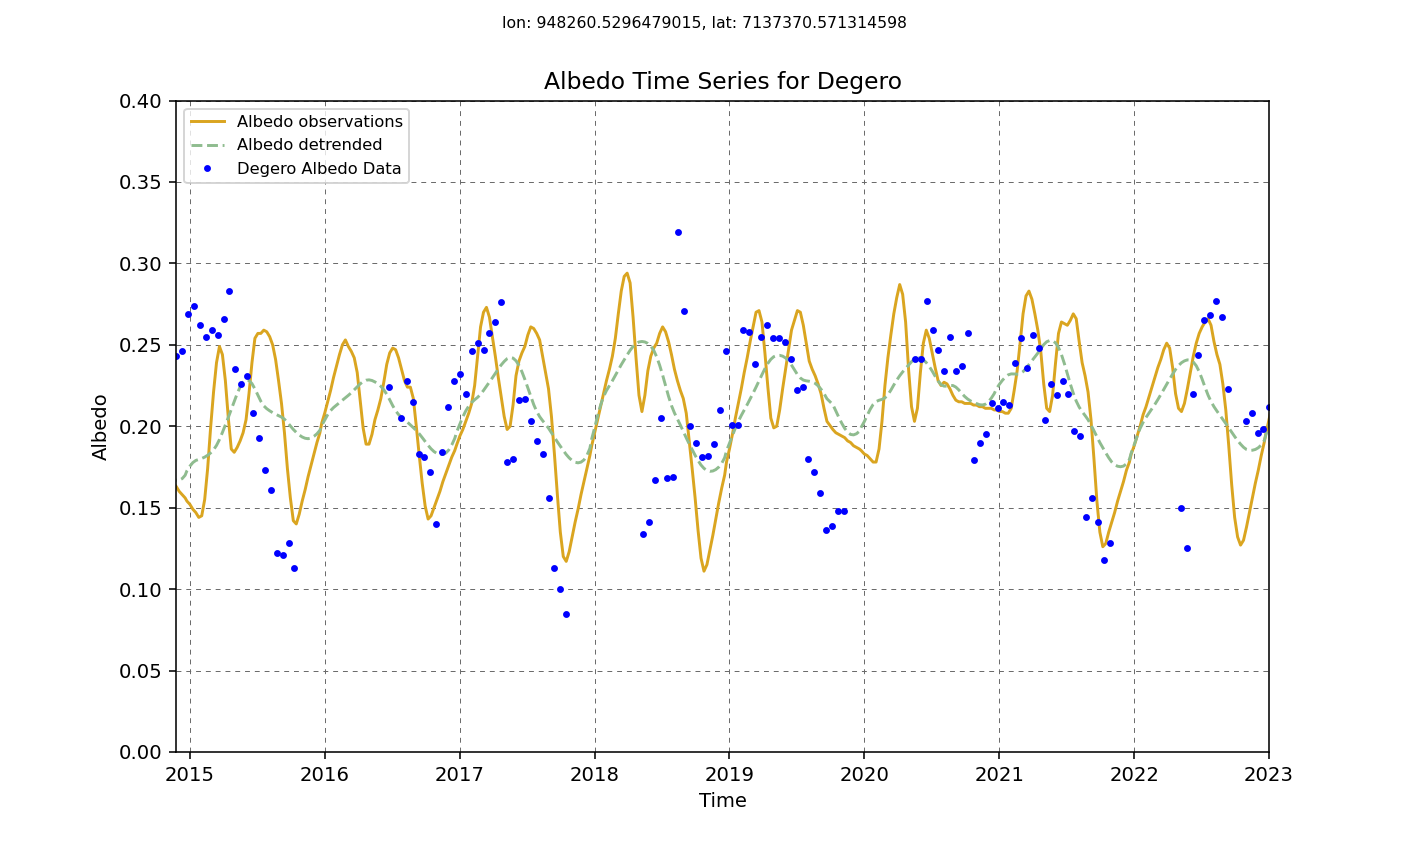

In [30]:

# Create the time axis for the degero.txt data (every 16 days starting from 2014-11-25)
time = pd.date_range(start='2014-11-25', periods=len(data), freq='16D')

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot albedo observations
ax.plot(xr_albedo['albedo'].time.values, 
        xr_albedo['albedo'].sel(latitude=y, longitude=x, method='nearest').data,
       color='goldenrod', label="Albedo observations")

# Plot detrended albedo
ax.plot(xr_albedoDetrended['albedo'].time.values, 
        xr_albedoDetrended['albedo'].sel(latitude=y, longitude=x, method='nearest').data,
       color='darkseagreen', label="Albedo detrended", linestyle='--')

# Plot the data from the degero.txt file with the time axis
ax.plot(time, data, marker='.', linestyle=' ', markersize=5, color='blue', label="Degero Albedo Data")

# Set title and labels
ax.set_title(f'Albedo Time Series for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('Albedo')

# Set y and x limits
ax.set_ylim(0, 0.4)
ax.set_xlim([datetime(2014, 11, 25), datetime(2023, 1, 1)])

# Customize grid and legend
plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='upper left', fontsize='small')

# Show the plot
plt.show()


<IPython.core.display.Javascript object>


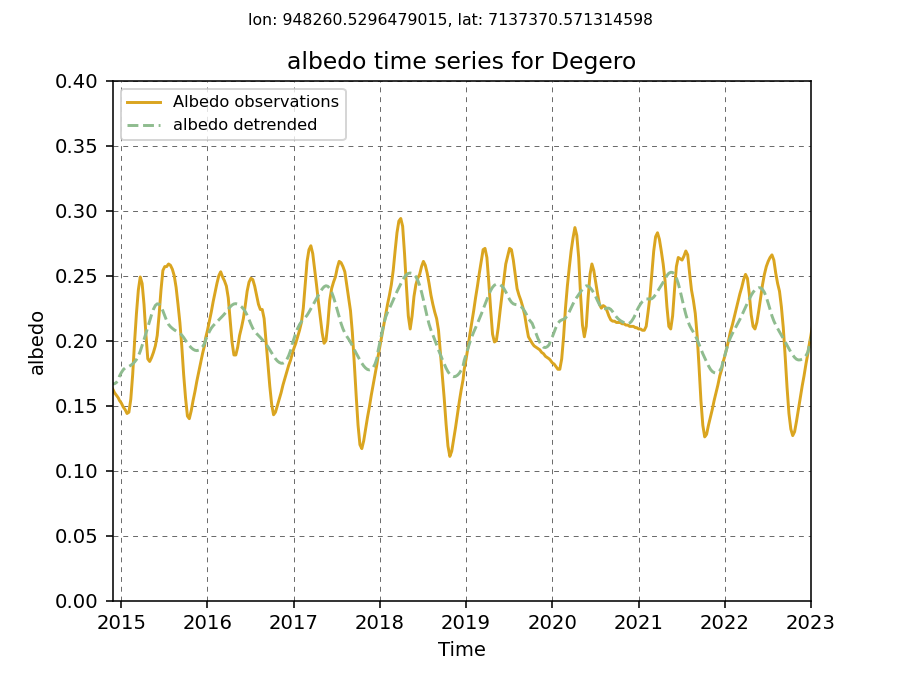

In [29]:
fig, ax = plt.subplots()

ax.plot(xr_albedo['albedo'].time.values, 
        xr_albedo['albedo'].sel(latitude=y, longitude=x, method='nearest').data,
       color='goldenrod', label="Albedo observations")

ax.plot(xr_albedoDetrended['albedo'].time.values, 
        xr_albedoDetrended['albedo'].sel(latitude=y, longitude=x, method='nearest').data,
       color='darkseagreen', label="albedo detrended",linestyle='--')

ax.set_title(f'albedo time series for {site}')
fig.suptitle(f'lon: {x}, lat: {y}', fontsize=8)
ax.set_xlabel('Time')
ax.set_ylabel('albedo')

ax.set_ylim(0,0.4)
ax.set_xlim([datetime(2014, 11, 25), datetime(2023, 1, 1)])

plt.grid(linestyle=(0, (5, 5)), linewidth=0.5, color='dimgray')
ax.legend(loc='upper left', fontsize='small')
# fig.savefig(f'/workspace/WorldPeatland/visualisation/ts_vis/{site}.albedo.png', dpi=300)
plt.show()